# Vector Operations

*Course notes for **Math for Machine Learning**, C1 · W3 · L1 · V03 — "Vector Operations" (DeepLearning.AI).*

Just as numbers can be added, subtracted, and scaled, so can **vectors** — and each operation has a clean **component-wise** rule and a **geometric** picture. This lecture covers:

- **Addition** and **subtraction** (component-wise; the parallelogram rule).
- **Distance between vectors** via the norm of their difference (used everywhere in ML as a similarity measure).
- **Scalar multiplication** (stretching and reflecting).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. Adding vectors

To add two vectors you simply **add their coordinates**. For $u = (4, 1)$ and $v = (1, 3)$:

$$ u + v = (4+1,\; 1+3) = (5, 4). $$

**Geometric interpretation:** the sum is the **diagonal of the parallelogram** formed by $u$ and $v$ (place them tail-to-tail).

In [2]:
u = np.array([4, 1])
v = np.array([1, 3])
s = u + v
print('u + v =', s)

u + v = [5 4]


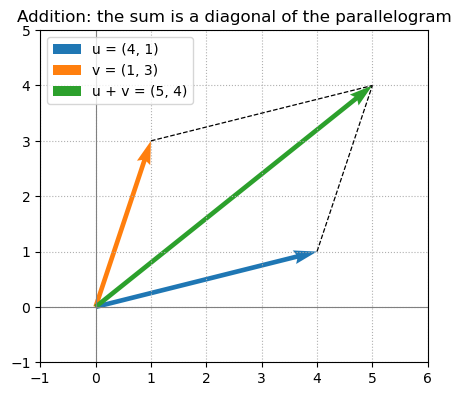

In [3]:
# Parallelogram rule for u + v
fig, ax = plt.subplots(figsize=(5, 5))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.012)
ax.quiver(0, 0, u[0], u[1], color='C0', **opts, label='u = (4, 1)')
ax.quiver(0, 0, v[0], v[1], color='C1', **opts, label='v = (1, 3)')
ax.quiver(0, 0, s[0], s[1], color='C2', **opts, label='u + v = (5, 4)')
# dashed parallelogram sides (translated copies)
ax.plot([u[0], s[0]], [u[1], s[1]], 'k--', lw=0.9)
ax.plot([v[0], s[0]], [v[1], s[1]], 'k--', lw=0.9)
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(loc='upper left')
ax.set_title('Addition: the sum is a diagonal of the parallelogram')
plt.show()

## 2. Subtracting vectors

Subtraction is also done **component by component**:

$$ v - u = (1-4,\; 3-1) = (-3, 2). $$

**Geometric interpretation:** the difference is the **other diagonal** of the parallelogram. Translated, the vector $v - u$ is exactly the arrow that **joins the tip of $u$ to the tip of $v$** — which is why the difference measures how far apart the two vectors are.

In [4]:
d = v - u
print('v - u =', d)

v - u = [-3  2]


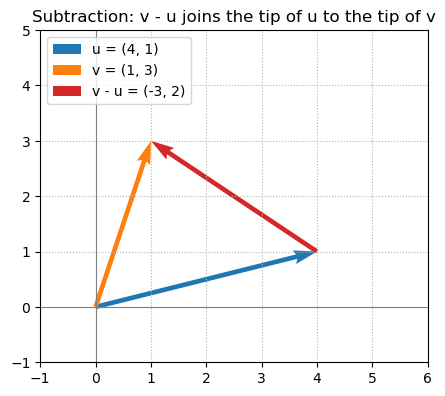

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.012)
ax.quiver(0, 0, u[0], u[1], color='C0', **opts, label='u = (4, 1)')
ax.quiver(0, 0, v[0], v[1], color='C1', **opts, label='v = (1, 3)')
# difference drawn in place: from tip of u to tip of v
ax.quiver(u[0], u[1], d[0], d[1], color='C3', **opts, label='v - u = (-3, 2)')
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(loc='upper left')
ax.set_title('Subtraction: v - u joins the tip of u to the tip of v')
plt.show()

## 3. General definition

For two vectors $x = (x_1, \dots, x_n)$ and $y = (y_1, \dots, y_n)$:

$$ x + y = (x_1 + y_1,\; \dots,\; x_n + y_n), \qquad x - y = (x_1 - y_1,\; \dots,\; x_n - y_n). $$

Each rule works **component by component**, so $x$ and $y$ must have the **same number of components**. In NumPy this is just `x + y` / `x - y` (element-wise).

In [6]:
x = np.array([2.0, -1.0, 5.0, 0.5])
y = np.array([1.0,  3.0, 2.0, 1.5])
print('x + y =', x + y)
print('x - y =', x - y)

x + y = [3. 2. 7. 2.]
x - y = [ 1. -4.  3. -1.]


## 4. Distance between vectors

The difference tells you **how far apart** two vectors are: take the **norm of the difference**. How different is $(1, 5)$ from $(6, 2)$?

- **$L_1$ distance** $= \|(1,5) - (6,2)\|_1 = |{-5}| + |3| = 8.$
- **$L_2$ distance** $= \|(1,5) - (6,2)\|_2 = \sqrt{(-5)^2 + 3^2} = \sqrt{34} \approx 5.83.$

In **machine learning** these distances are everywhere: you constantly measure the **similarity** between data points, and the norm of a difference is the natural way to do it.

In [7]:
p = np.array([1, 5])
q = np.array([6, 2])
diff = p - q
print('p - q          =', diff)
print('L1 distance    =', np.linalg.norm(diff, 1))
print('L2 distance    =', round(float(np.linalg.norm(diff, 2)), 2))

p - q          = [-5  3]
L1 distance    = 8.0
L2 distance    = 5.83


## 5. Scalar multiplication

Multiplying a vector by a **scalar** $\lambda$ multiplies **each component** by $\lambda$ (element-wise):

$$ \lambda\,x = (\lambda x_1,\; \lambda x_2,\; \dots,\; \lambda x_n). $$

**Geometrically:**
- $\lambda = 3$ on $(1, 2)$ gives $(3, 6)$ — the vector is **stretched** by a factor of 3 (same direction).
- $\lambda = -2$ on $(1, 2)$ gives $(-2, -4)$ — stretched by 2 **and reflected** through the origin (opposite direction).

In [8]:
a = np.array([1, 2])
print('3 * a  =', 3 * a)
print('-2 * a =', -2 * a)

3 * a  = [3 6]
-2 * a = [-2 -4]


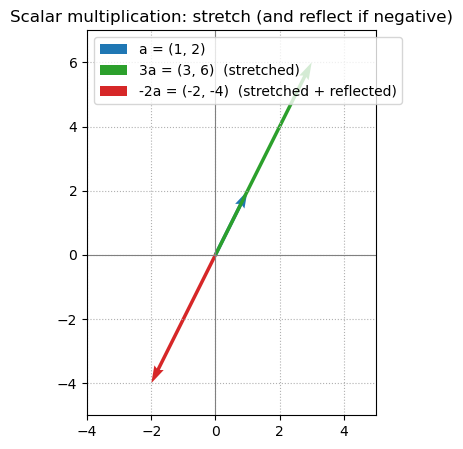

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.012)
ax.quiver(0, 0, a[0], a[1], color='C0', **opts, label='a = (1, 2)')
ax.quiver(0, 0, *(3 * a), color='C2', **opts, label='3a = (3, 6)  (stretched)')
ax.quiver(0, 0, *(-2 * a), color='C3', **opts, label='-2a = (-2, -4)  (stretched + reflected)')
ax.set_xlim(-4, 5); ax.set_ylim(-5, 7)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(loc='upper left')
ax.set_title('Scalar multiplication: stretch (and reflect if negative)')
plt.show()

## Summary

- **Addition / subtraction** are done **component-wise**; vectors must share the same dimension.
  - $u + v$ is a **diagonal of the parallelogram**; $v - u$ is the **other diagonal**, and (translated) it joins the tip of $u$ to the tip of $v$.
- **Distance between vectors** $=$ **norm of their difference** ($L_1$ or $L_2$) — the workhorse **similarity** measure in ML.
- **Scalar multiplication** $\lambda x$ scales each component: it **stretches** the vector by $|\lambda|$ and **reflects** it through the origin when $\lambda < 0$.